Loaded 185,617 rows x 43 columns
Breach prevalence: 20.73%  →  random-guess PR-AUC baseline ≈ 0.2073
Train-only sites (excluded from test evaluation): {'USGS-05480986'}
Including geo columns as regional proxies: ['w_surplus_long', 'w_Alfalfa_long', 'w_Corn_long', 'w_Fallow_long', 'w_Hay_Pasture_long', 'w_Nonag_long', 'w_Other_long', 'w_Small_Grains_long', 'w_Soybeans_long']

Feature matrix: 53 features
Grid search space: 8 configurations

Starting 4-Fold Spatial CV with Inner Grid Search

--- Outer Fold 1/4 ---
  Best inner PR-AUC : 0.4389
  Best params       : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
  Outer PR-AUC      : 0.5909

--- Outer Fold 2/4 ---
  Best inner PR-AUC : 0.5241
  Best params       : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}

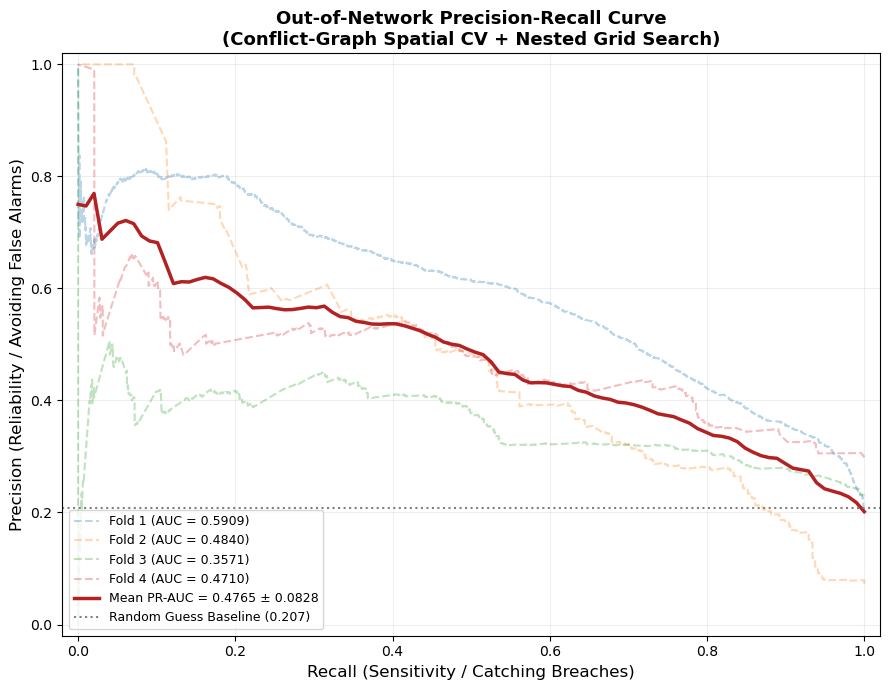


Top 20 Feature Importances (last fold model):
month_cos                   0.188
day_of_year                 0.069
w_Hay_Pasture_med           0.046
spring_rain_30d             0.041
rain_roll_30d               0.038
w_Hay_Pasture_long          0.035
rain_roll_60d               0.035
week                        0.032
year                        0.030
w_Corn_med                  0.027
w_Corn_long                 0.027
rain_roll_90d               0.026
day_of_year_sin             0.026
log_basin_area              0.024
week_cos                    0.023
month_sin                   0.021
w_Fallow_med                0.021
w_Alfalfa_short             0.021
w_Corn_short                0.019
site_historical_mean_rain   0.019


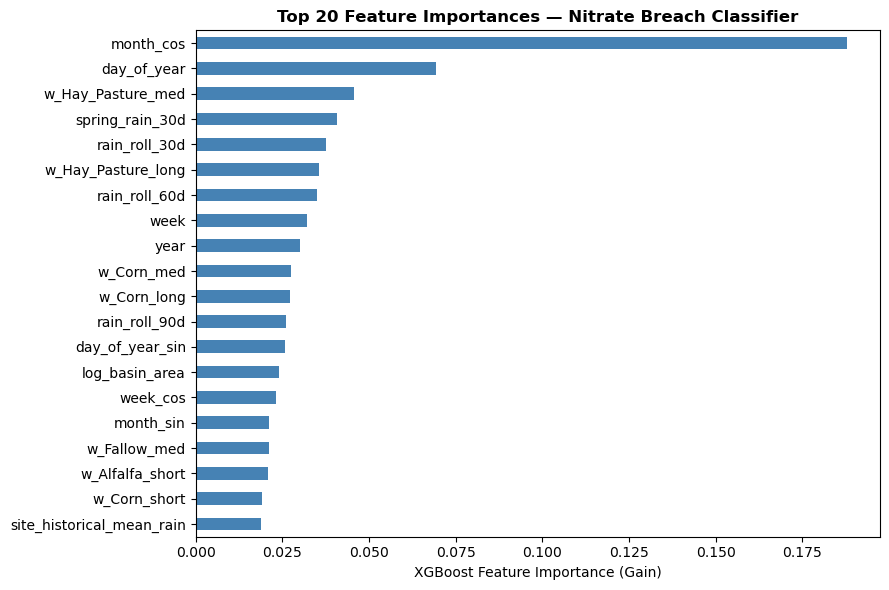


Best hyperparameters selected per outer fold:
  Fold 1: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
  Fold 2: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
  Fold 3: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
  Fold 4: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}

FOLD 3 DIAGNOSTIC
  Test sites : 24
  Train sites: 61

Per-site summary (Fold 3 test sites), sorted by mean nitrate:
               n_records  breach_rate  nitrate_con_mean  nitrate_con_std  basin_area_mean  w_Corn_short_mean  w_surplus_short_mean
site_

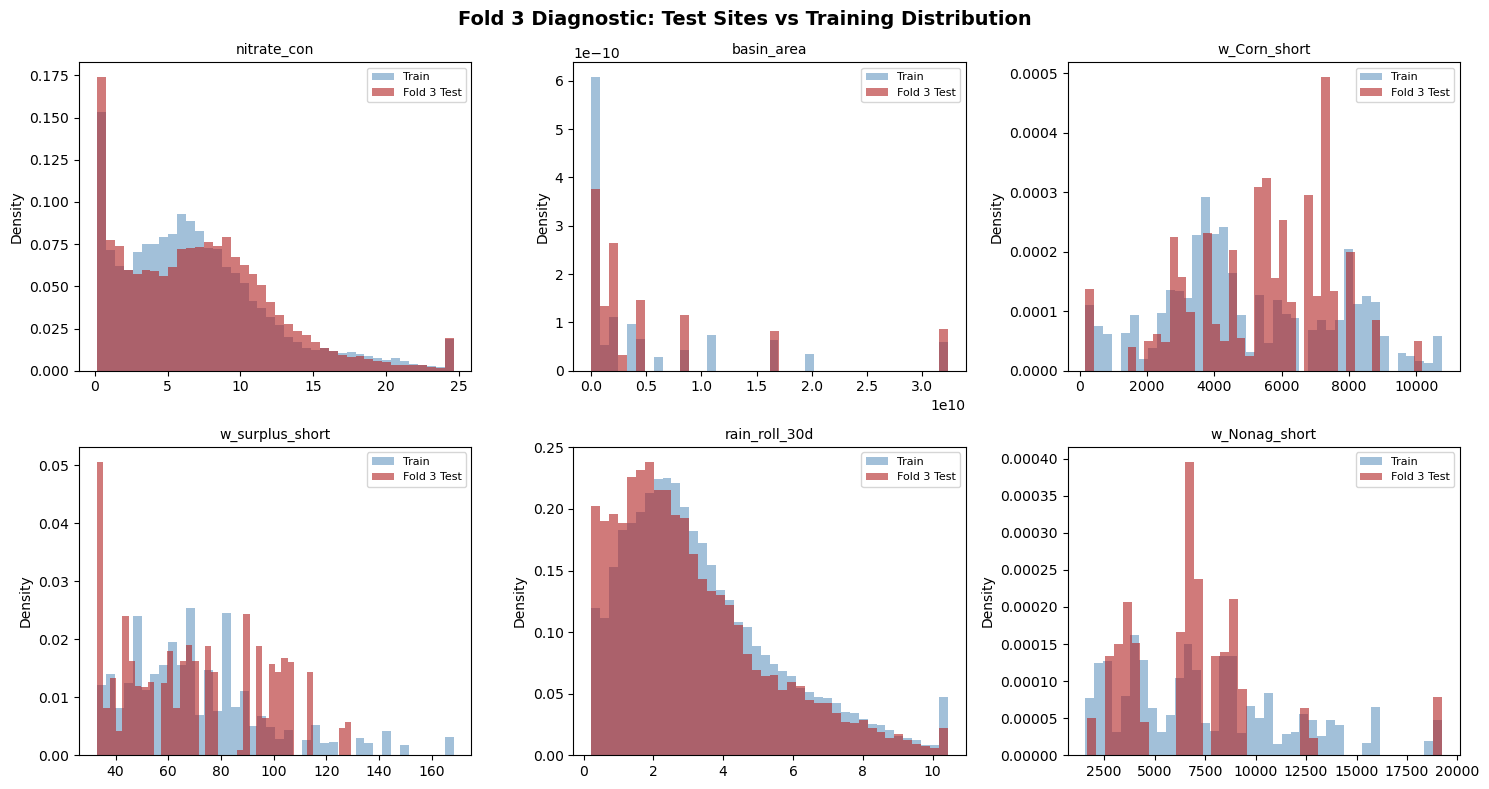

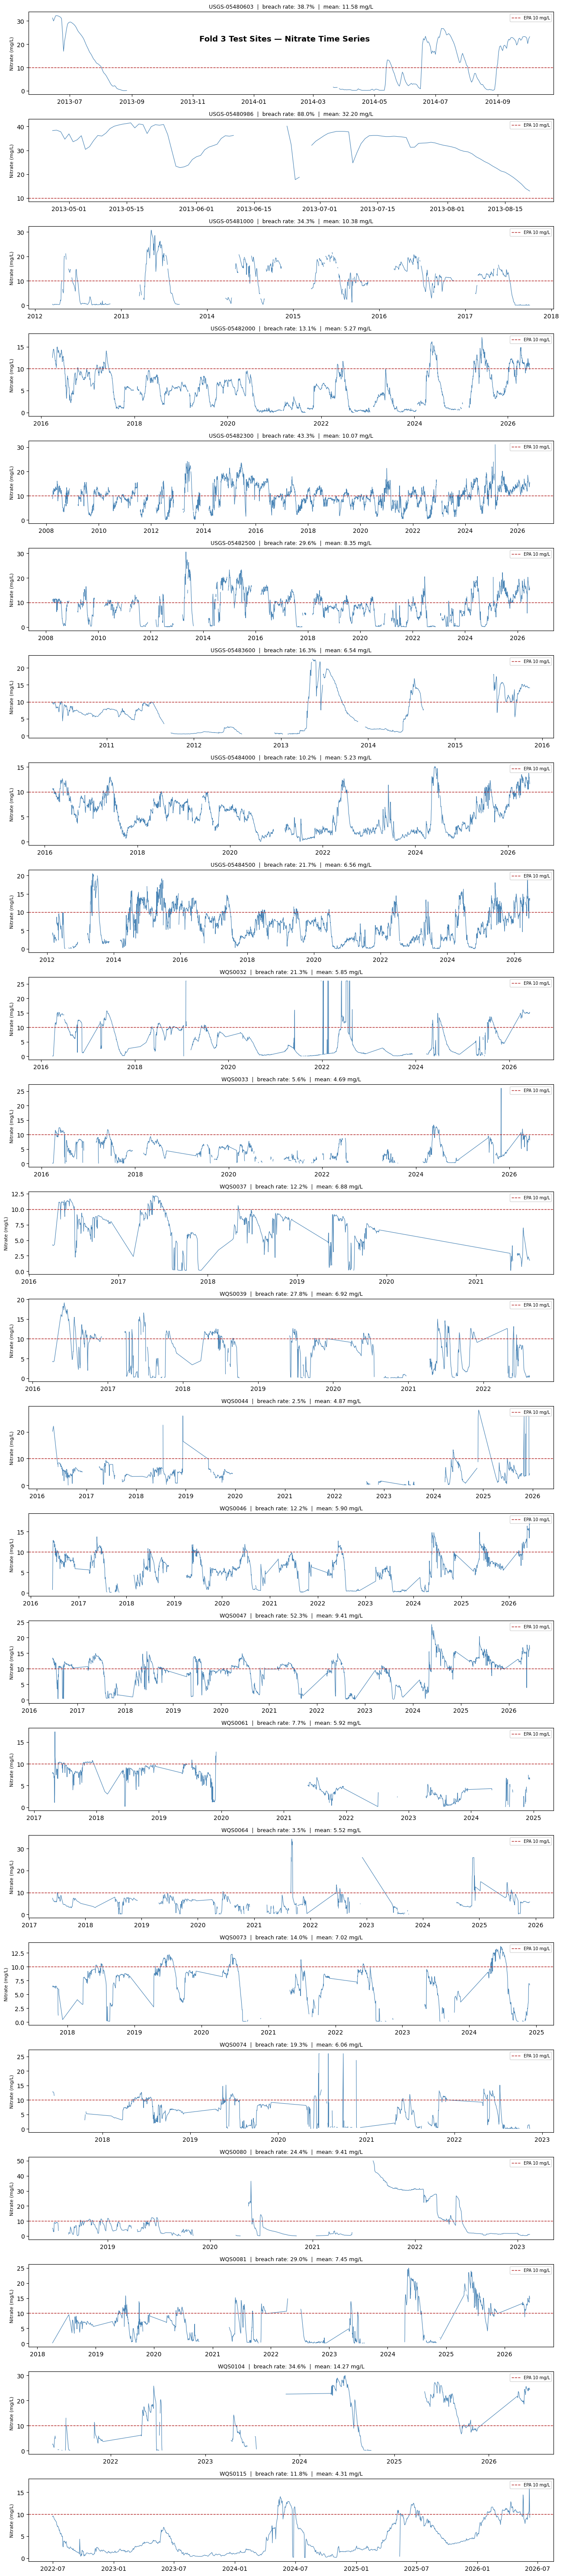

In [ ]:
import sys
sys.path.insert(0, "../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.splits import make_folds, audit_split

from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import ParameterGrid

# =============================================================================
# 1. LOAD DATA
# =============================================================================
df = pd.read_parquet('df_master_raw_hydrology.parquet')
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

# =============================================================================
# 2. DEFINE BINARY TARGET: EPA 10 mg/L MCL
# =============================================================================
EPA_THRESHOLD = 10.0
df['nitrate_breach'] = (df['nitrate_con'] > EPA_THRESHOLD).astype(int)
breach_rate = df['nitrate_breach'].mean()
print(f"Breach prevalence: {breach_rate:.2%}  →  random-guess PR-AUC baseline ≈ {breach_rate:.4f}")

# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================

# --- 3a. Cyclic Encoding of Temporal Features ---
# Raw month/doy/week integers are ordinal, not cyclic: the model would see Dec(12)
# and Jan(1) as maximally distant when they are adjacent. Sin/cos encoding wraps
# the calendar so proximity is preserved. We also retain the raw integers because
# XGBoost can use both — the integer captures monotone seasonal trends while the
# trig pair captures cyclic adjacency.
def add_cyclic(df, col, period):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
    return df

df = add_cyclic(df, 'month',       period=12)
df = add_cyclic(df, 'day_of_year', period=365)
df = add_cyclic(df, 'week',        period=52)

# --- 3b. Seasonal Interaction Features ---
# Fertilizer application peaks Apr-May; spring/summer rain flushes nitrate into
# streams via tile drains. Encoding these cross-products makes the dominant
# physical loading mechanism explicit rather than requiring the booster to
# reconstruct it through many nested splits.
df['spring_flag'] = df['month'].isin([3, 4, 5]).astype(int)
df['summer_flag'] = df['month'].isin([6, 7, 8]).astype(int)

df['spring_rain_7d']   = df['spring_flag'] * df['rain_roll_7d']
df['spring_rain_30d']  = df['spring_flag'] * df['rain_roll_30d']
df['spring_corn_rain'] = df['spring_flag'] * df['w_Corn_short'] * df['rain_roll_7d']

if 'basin_area' in df.columns:
    df['volume_proxy_30d'] = df['rain_roll_30d'] * df['basin_area']
    df['volume_proxy_90d'] = df['rain_roll_90d'] * df['basin_area']

# Log-transform basin area: sites span four orders of magnitude (1.8M to 4.2B),
# so raw area causes XGBoost to waste splits on scale rather than hydrology.
# Log compresses the range and lets the model split meaningfully across sizes.
df["log_basin_area"] = np.log1p(df["basin_area"])

# Historical nitrate baselines intentionally excluded.
# Providing the model with a site's prior mean nitrate (even leak-free) is
# nearly circular — it answers "will this site breach?" with "has it breached
# before?", which trivializes the prediction and tells us nothing about the
# physical drivers (land use, rainfall, basin geometry) we actually care about.
# The interesting question is whether those drivers alone predict breach risk
# at sites where we may have no prior nitrate record at all.

# =============================================================================
# 4. DEFINE FEATURE COLUMNS
# =============================================================================
id_col    = 'site_uid' if 'site_uid' in df.columns else 'site_id'
drop_cols = {id_col, 'date', 'nitrate_con', 'nitrate_breach',
             'basin_area',   # replaced by log_basin_area
            }

# --- Lat/lon: include, with explanation ---
# The conflict-graph splitter guarantees that no held-out site shares spatial
# containment AND temporal overlap with any training site. Coordinates therefore
# cannot function as a look-up key for test-site target values. Instead they act
# as legitimate regional proxies for geology, climate zone, and soil type —
# information that genuinely predicts nitrate regime. We keep them.
# (If you ever switch to a weaker splitter, revisit this decision.)
geo_cols = [c for c in df.columns
            if any(k in c.lower() for k in ['lat', 'lon', 'lng', 'latitude', 'longitude'])]
if geo_cols:
    print(f"Including geo columns as regional proxies: {geo_cols}")

feature_cols = [c for c in df.columns if c not in drop_cols]
print(f"\nFeature matrix: {len(feature_cols)} features")

# =============================================================================
# 5. HYPERPARAMETER GRID
# =============================================================================
PARAM_GRID = list(ParameterGrid({
    'max_depth':        [4, 6],      # most impactful structural param
    'learning_rate':    [0.03, 0.05],
    'n_estimators':     [600],       # ceiling; early stopping fires well before this
    'subsample':        [0.8],       # fixed — low sensitivity, saves 2x fits
    'colsample_bytree': [0.8],       # fixed — low sensitivity, saves 2x fits
    'reg_alpha':        [0.0],       # fixed — tree structure already regularizes
    'reg_lambda':       [1.0],       # fixed — XGBoost default is well-calibrated
    'min_child_weight': [3, 10],     # min hessian sum per leaf — controls overfitting
}))
# 2 × 2 × 2 = 8 configs; 8 × 2 inner × 4 outer = 64 total fits
print(f"Grid search space: {len(PARAM_GRID)} configurations")

# =============================================================================
# 6. OUTER FOLDS  (built once, reused in every outer iteration)
# =============================================================================
RANDOM_STATE = 42
NUM_FOLDS    = 4

# make_folds operates on ALL sites from get_site_ids() internally.
# We filter its output to get train/test site lists for each outer fold.
outer_folds = make_folds(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_STATE)

plt.figure(figsize=(9, 7))
mean_recall         = np.linspace(0, 1, 100)
precisions_all      = []
fold_auc_scores     = []
best_params_by_fold = []

print(f"\n{'='*60}")
print(f"Starting {NUM_FOLDS}-Fold Spatial CV with Inner Grid Search")
print(f"{'='*60}\n")

# =============================================================================
# 7. NESTED CV LOOP
# =============================================================================
for fold_idx in range(NUM_FOLDS):
    print(f"--- Outer Fold {fold_idx + 1}/{NUM_FOLDS} ---")

    # --- Outer split ---
    test_sites  = outer_folds.index[outer_folds.fold == fold_idx].tolist()
    train_sites = outer_folds.index[outer_folds.fold != fold_idx].tolist()

    assert audit_split(train_sites, test_sites).query("severity == 'hard'").empty, \
        f"Fold {fold_idx + 1}: hard spatial leak detected — check conflict graph!"

    df_train_outer = df[df[id_col].isin(train_sites)]
    df_test_outer  = df[df[id_col].isin(test_sites)]

    X_test_outer = df_test_outer[feature_cols]
    y_test_outer = df_test_outer['nitrate_breach']

    # --- Inner folds for hyperparameter tuning ---
    # make_folds has no site_pool argument, so we call it globally and then
    # restrict to the training sites of this outer fold by filtering the table.
    inner_fold_table = make_folds(
        n_splits=2,   # 2 inner folds — enough to rank configs, much faster
        shuffle=True,
        random_state=RANDOM_STATE
    )
    # Keep only rows that correspond to outer-training sites, then re-index
    # folds 0..NUM_FOLDS-2 within that restricted pool.
    inner_fold_table = inner_fold_table[inner_fold_table.index.isin(train_sites)].copy()

    # --- Inner grid search ---
    best_inner_auc = -1.0
    best_params    = PARAM_GRID[0]

    for params in PARAM_GRID:
        inner_aucs = []

        for inner_idx in inner_fold_table['fold'].unique():
            inner_test_sites  = inner_fold_table.index[inner_fold_table.fold == inner_idx].tolist()
            inner_train_sites = inner_fold_table.index[inner_fold_table.fold != inner_idx].tolist()

            # Restrict both pools to outer-training sites (already guaranteed by
            # the filter above, but explicit for clarity)
            inner_train_sites = [s for s in inner_train_sites if s in set(train_sites)]
            inner_test_sites  = [s for s in inner_test_sites  if s in set(train_sites)]

            df_it = df_train_outer[df_train_outer[id_col].isin(inner_train_sites)]
            df_iv = df_train_outer[df_train_outer[id_col].isin(inner_test_sites)]

            X_it, y_it = df_it[feature_cols], df_it['nitrate_breach']
            X_iv, y_iv = df_iv[feature_cols], df_iv['nitrate_breach']

            # Downsample majority class 2:1 on training split only
            idx_neg = y_it[y_it == 0].index
            idx_pos = y_it[y_it == 1].index
            n_sample = min(len(idx_neg), len(idx_pos) * 2)
            rng = np.random.default_rng(RANDOM_STATE)
            sampled_neg = rng.choice(idx_neg, size=n_sample, replace=False)
            bal_idx = np.concatenate([idx_pos, sampled_neg])
            X_bal, y_bal = X_it.loc[bal_idx], y_it.loc[bal_idx]

            imbalance_ratio = (y_bal == 0).sum() / max(1, (y_bal == 1).sum())

            m = XGBClassifier(
                objective='binary:logitraw',
                eval_metric='aucpr',
                early_stopping_rounds=25,
                tree_method='hist',
                n_jobs=-1,
                random_state=RANDOM_STATE,
                scale_pos_weight=imbalance_ratio,
                **params
            )
            m.fit(X_bal, y_bal, eval_set=[(X_iv, y_iv)], verbose=False)

            scores = m.predict(X_iv, output_margin=True)
            prec, rec, _ = precision_recall_curve(y_iv, scores)
            inner_aucs.append(auc(rec, prec))

        mean_inner_auc = np.mean(inner_aucs)
        if mean_inner_auc > best_inner_auc:
            best_inner_auc = mean_inner_auc
            best_params    = params

    best_params_by_fold.append(best_params)
    print(f"  Best inner PR-AUC : {best_inner_auc:.4f}")
    print(f"  Best params       : {best_params}")

    # --- Retrain on full outer training set with winning params ---
    X_train_full = df_train_outer[feature_cols]
    y_train_full = df_train_outer['nitrate_breach']

    idx_neg = y_train_full[y_train_full == 0].index
    idx_pos = y_train_full[y_train_full == 1].index
    n_sample = min(len(idx_neg), len(idx_pos) * 2)
    rng = np.random.default_rng(RANDOM_STATE)
    sampled_neg = rng.choice(idx_neg, size=n_sample, replace=False)
    bal_idx = np.concatenate([idx_pos, sampled_neg])
    X_bal_full = X_train_full.loc[bal_idx]
    y_bal_full = y_train_full.loc[bal_idx]
    imbalance_ratio = (y_bal_full == 0).sum() / max(1, (y_bal_full == 1).sum())

    final_model = XGBClassifier(
        objective='binary:logitraw',
        eval_metric='aucpr',
        early_stopping_rounds=30,
        tree_method='hist',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        scale_pos_weight=imbalance_ratio,
        **best_params
    )
    final_model.fit(
        X_bal_full, y_bal_full,
        eval_set=[(X_test_outer, y_test_outer)],
        verbose=False
    )

    # --- Outer evaluation ---
    scores_outer = final_model.predict(X_test_outer, output_margin=True)
    prec_outer, rec_outer, _ = precision_recall_curve(y_test_outer, scores_outer)
    fold_auc = auc(rec_outer, prec_outer)
    fold_auc_scores.append(fold_auc)

    plt.plot(rec_outer, prec_outer, alpha=0.3, linestyle='--',
             label=f'Fold {fold_idx + 1} (AUC = {fold_auc:.4f})')

    interp_prec = np.interp(mean_recall, rec_outer[::-1], prec_outer[::-1])
    precisions_all.append(interp_prec)

    print(f"  Outer PR-AUC      : {fold_auc:.4f}\n")

# =============================================================================
# 8. AGGREGATE & PLOT RESULTS
# =============================================================================
mean_auc = np.mean(fold_auc_scores)
std_auc  = np.std(fold_auc_scores)

print(f"{'='*60}")
print(f"FINAL RESULTS")
print(f"Mean Out-of-Network PR-AUC : {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Random-guess baseline      : {breach_rate:.4f}")
print(f"{'='*60}")

mean_precision = np.mean(precisions_all, axis=0)
mean_curve_auc = auc(mean_recall, mean_precision)

plt.plot(mean_recall, mean_precision, color='firebrick', lw=2.5,
         label=f'Mean PR-AUC = {mean_curve_auc:.4f} ± {std_auc:.4f}')
plt.axhline(y=breach_rate, color='gray', linestyle=':', lw=1.5,
            label=f'Random Guess Baseline ({breach_rate:.3f})')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Recall (Sensitivity / Catching Breaches)', fontsize=12)
plt.ylabel('Precision (Reliability / Avoiding False Alarms)', fontsize=12)
plt.title('Out-of-Network Precision-Recall Curve\n(Conflict-Graph Spatial CV + Nested Grid Search)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pr_curve_nitrate_breach.png', dpi=150)
plt.show()

# =============================================================================
# 9. FEATURE IMPORTANCE (last fold model — for inspection)
# =============================================================================
importances = pd.Series(
    final_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances (last fold model):")
print(importances.head(20).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
importances.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — Nitrate Breach Classifier', fontweight='bold')
ax.set_xlabel('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('feature_importance_nitrate_breach.png', dpi=150)
plt.show()

# =============================================================================
# 10. BEST HYPERPARAMETERS PER FOLD
# =============================================================================
print("\nBest hyperparameters selected per outer fold:")
for i, p in enumerate(best_params_by_fold):
    print(f"  Fold {i + 1}: {p}")

# =============================================================================
# 11. FOLD 3 DIAGNOSTIC
# =============================================================================
FOLD3_IDX = 2  # 0-indexed

fold3_test_sites  = outer_folds.index[outer_folds.fold == FOLD3_IDX].tolist()
fold3_train_sites = outer_folds.index[outer_folds.fold != FOLD3_IDX].tolist()

df_fold3_test  = df[df[id_col].isin(fold3_test_sites)]
df_fold3_train = df[df[id_col].isin(fold3_train_sites)]

print(f"\n{'='*60}")
print(f"FOLD 3 DIAGNOSTIC")
print(f"  Test sites : {len(fold3_test_sites)}")
print(f"  Train sites: {len(fold3_train_sites)}")
print(f"{'='*60}")

# --- Per-site summary for test sites ---
KEY_FEATURES = [
    'nitrate_con', 'nitrate_breach', 'basin_area',
    'w_Corn_short', 'w_surplus_short', 'rain_roll_30d',
    'rain_roll_90d', 'w_Nonag_short', 'w_Hay_Pasture_short',
]
available = [c for c in KEY_FEATURES if c in df.columns]

site_stats = (
    df_fold3_test
    .groupby(id_col)[available]
    .agg(['mean', 'std', 'median'])
)
site_stats.columns = ['_'.join(c) for c in site_stats.columns]
site_stats['breach_rate'] = df_fold3_test.groupby(id_col)['nitrate_breach'].mean()
site_stats['n_records']   = df_fold3_test.groupby(id_col)['nitrate_breach'].count()
site_stats = site_stats.sort_values('nitrate_con_mean', ascending=False)

print("\nPer-site summary (Fold 3 test sites), sorted by mean nitrate:")
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.3f}'.format)
print(site_stats[['n_records', 'breach_rate', 'nitrate_con_mean', 'nitrate_con_std',
                   'basin_area_mean', 'w_Corn_short_mean', 'w_surplus_short_mean']].to_string())

# --- Compare test vs train distributions on key features ---
compare_cols = ['nitrate_con', 'basin_area', 'w_Corn_short',
                'w_surplus_short', 'rain_roll_30d', 'rain_roll_90d']
compare_cols = [c for c in compare_cols if c in df.columns]

print(f"\n{'─'*60}")
print("Feature distribution comparison: Fold 3 test vs training data")
print(f"{'─'*60}")
print(f"{'Feature':<22}  {'Train mean':>10}  {'Test mean':>10}  {'Train median':>12}  {'Test median':>11}  {'Δ mean %':>9}")
print(f"{'─'*60}")
for col in compare_cols:
    tr_mean = df_fold3_train[col].mean()
    te_mean = df_fold3_test[col].mean()
    tr_med  = df_fold3_train[col].median()
    te_med  = df_fold3_test[col].median()
    delta   = (te_mean - tr_mean) / (abs(tr_mean) + 1e-9) * 100
    print(f"{col:<22}  {tr_mean:>10.3f}  {te_mean:>10.3f}  {tr_med:>12.3f}  {te_med:>11.3f}  {delta:>+9.1f}%")

# --- Breach rate comparison ---
train_breach = df_fold3_train['nitrate_breach'].mean()
test_breach  = df_fold3_test['nitrate_breach'].mean()
print(f"\n{'─'*60}")
print(f"Breach rate  →  Train: {train_breach:.2%}   Test: {test_breach:.2%}")
print(f"{'─'*60}")

# --- Basin area distribution: are test basins outliers? ---
print(f"\nBasin area percentiles (train vs test):")
for pct in [10, 25, 50, 75, 90]:
    tr_p = df_fold3_train['basin_area'].quantile(pct/100) if 'basin_area' in df.columns else float('nan')
    te_p = df_fold3_test['basin_area'].quantile(pct/100)  if 'basin_area' in df.columns else float('nan')
    print(f"  p{pct:02d}:  Train {tr_p:>14.0f}   Test {te_p:>14.0f}")

# --- Visualizations ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Fold 3 Diagnostic: Test Sites vs Training Distribution', fontsize=14, fontweight='bold')

plot_cols = ['nitrate_con', 'basin_area', 'w_Corn_short',
             'w_surplus_short', 'rain_roll_30d', 'w_Nonag_short']
plot_cols = [c for c in plot_cols if c in df.columns]

for ax, col in zip(axes.flat, plot_cols):
    # Clip extreme tails for readability
    lo = df_fold3_train[col].quantile(0.01)
    hi = df_fold3_train[col].quantile(0.99)
    tr_clipped = df_fold3_train[col].clip(lo, hi)
    te_clipped = df_fold3_test[col].clip(lo, hi)

    ax.hist(tr_clipped, bins=40, alpha=0.5, color='steelblue',
            density=True, label='Train')
    ax.hist(te_clipped, bins=40, alpha=0.6, color='firebrick',
            density=True, label='Fold 3 Test')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fold3_diagnostic.png', dpi=150)
plt.show()

# --- Nitrate time series per test site ---
if 'date' in df.columns:
    fig, axes = plt.subplots(
        len(fold3_test_sites), 1,
        figsize=(13, 2.5 * len(fold3_test_sites)),
        sharex=False
    )
    if len(fold3_test_sites) == 1:
        axes = [axes]
    fig.suptitle('Fold 3 Test Sites — Nitrate Time Series', fontsize=13, fontweight='bold')

    for ax, site in zip(axes, fold3_test_sites):
        site_df = df_fold3_test[df_fold3_test[id_col] == site].sort_values('date')
        ax.plot(site_df['date'], site_df['nitrate_con'], lw=0.8, color='steelblue')
        ax.axhline(EPA_THRESHOLD, color='firebrick', linestyle='--', lw=1,
                   label='EPA 10 mg/L')
        br = site_df['nitrate_breach'].mean()
        ax.set_title(f"{site}  |  breach rate: {br:.1%}  |  mean: {site_df['nitrate_con'].mean():.2f} mg/L",
                     fontsize=9)
        ax.set_ylabel('Nitrate (mg/L)', fontsize=8)
        ax.legend(fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.savefig('fold3_timeseries.png', dpi=150)
    plt.show()

Loaded 185,617 rows x 43 columns
Breach prevalence: 20.73%  →  random-guess PR-AUC baseline ≈ 0.2073
Historical baseline features added.
  NaN rate: 0.00%
Including geo columns as regional proxies: ['w_surplus_long', 'w_Alfalfa_long', 'w_Corn_long', 'w_Fallow_long', 'w_Hay_Pasture_long', 'w_Nonag_long', 'w_Other_long', 'w_Small_Grains_long', 'w_Soybeans_long']

Feature matrix: 54 features
Grid search space: 8 configurations

Starting 4-Fold Spatial CV with Inner Grid Search

--- Outer Fold 1/4 ---
  Best inner PR-AUC : 0.4697
  Best params       : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
  Outer PR-AUC      : 0.6679

--- Outer Fold 2/4 ---
  Best inner PR-AUC : 0.6481
  Best params       : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
  Outer PR-AU

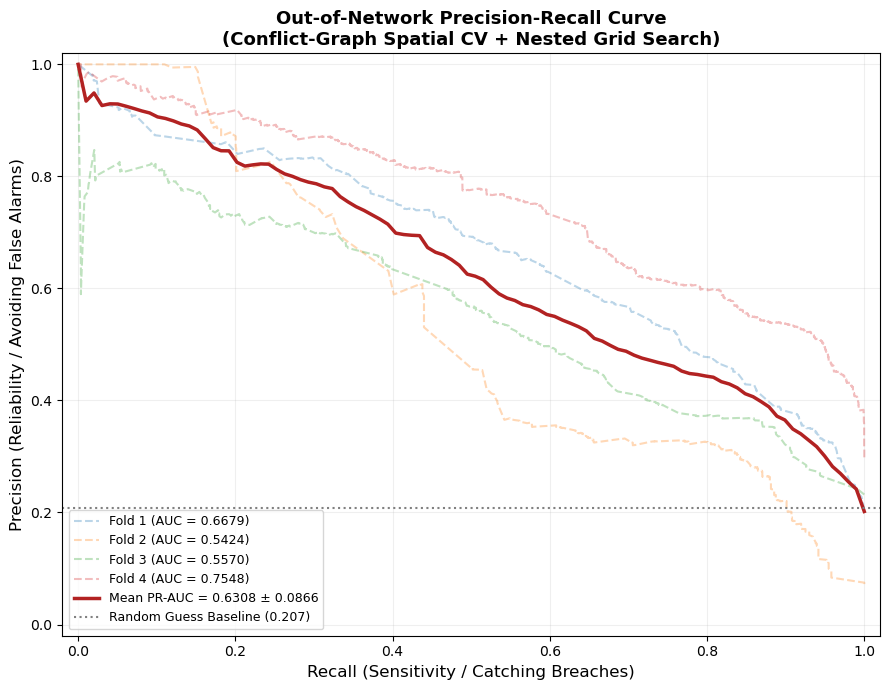


Top 20 Feature Importances (last fold model):
month_cos                      0.127
site_historical_mean_nitrate   0.063
month                          0.063
site_historical_breach_rate    0.050
w_Corn_med                     0.037
day_of_year                    0.035
spring_rain_30d                0.032
rain_roll_30d                  0.030
w_Nonag_long                   0.030
w_Corn_long                    0.029
rain_roll_60d                  0.028
day_of_year_sin                0.028
spring_rain_7d                 0.024
month_sin                      0.024
w_Hay_Pasture_long             0.022
week                           0.021
w_Fallow_med                   0.020
w_Soybeans_long                0.019
rain_roll_90d                  0.019
log_basin_area                 0.018


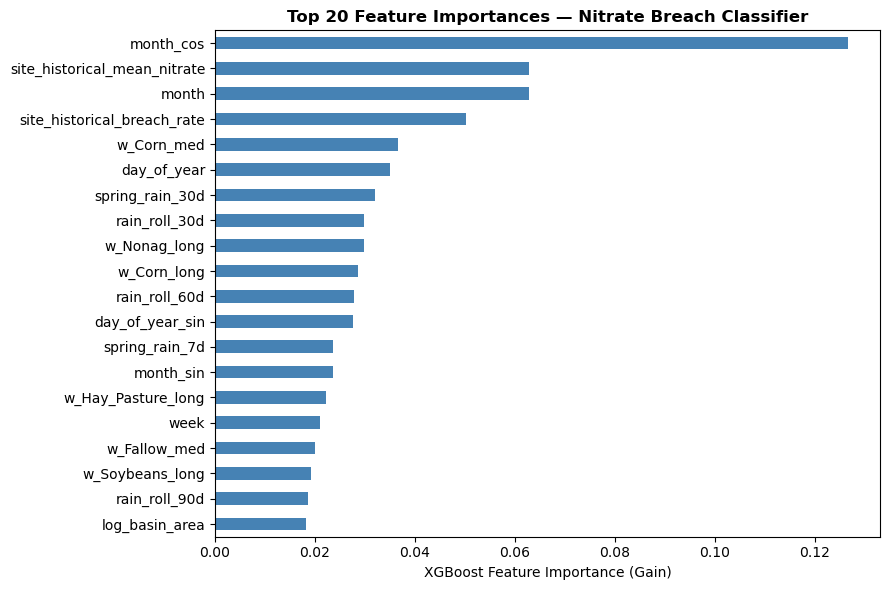


Best hyperparameters selected per outer fold:
  Fold 1: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
  Fold 2: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
  Fold 3: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
  Fold 4: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}

FOLD 3 DIAGNOSTIC
  Test sites : 24
  Train sites: 61

Per-site summary (Fold 3 test sites), sorted by mean nitrate:
               n_records  breach_rate  nitrate_con_mean  nitrate_con_std  basin_area_mean  w_Corn_short_mean  w_surplus_short_mean
site_u

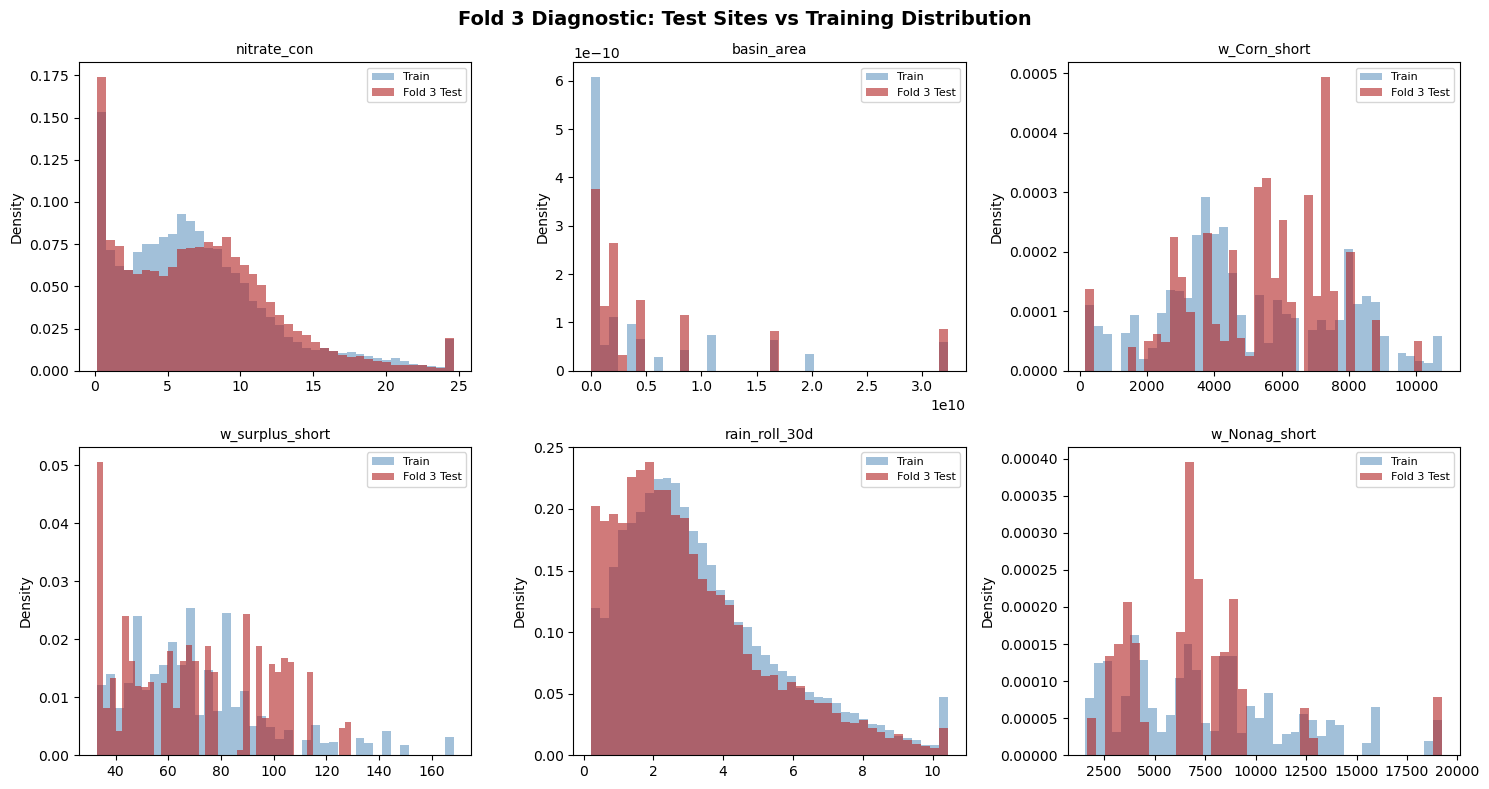

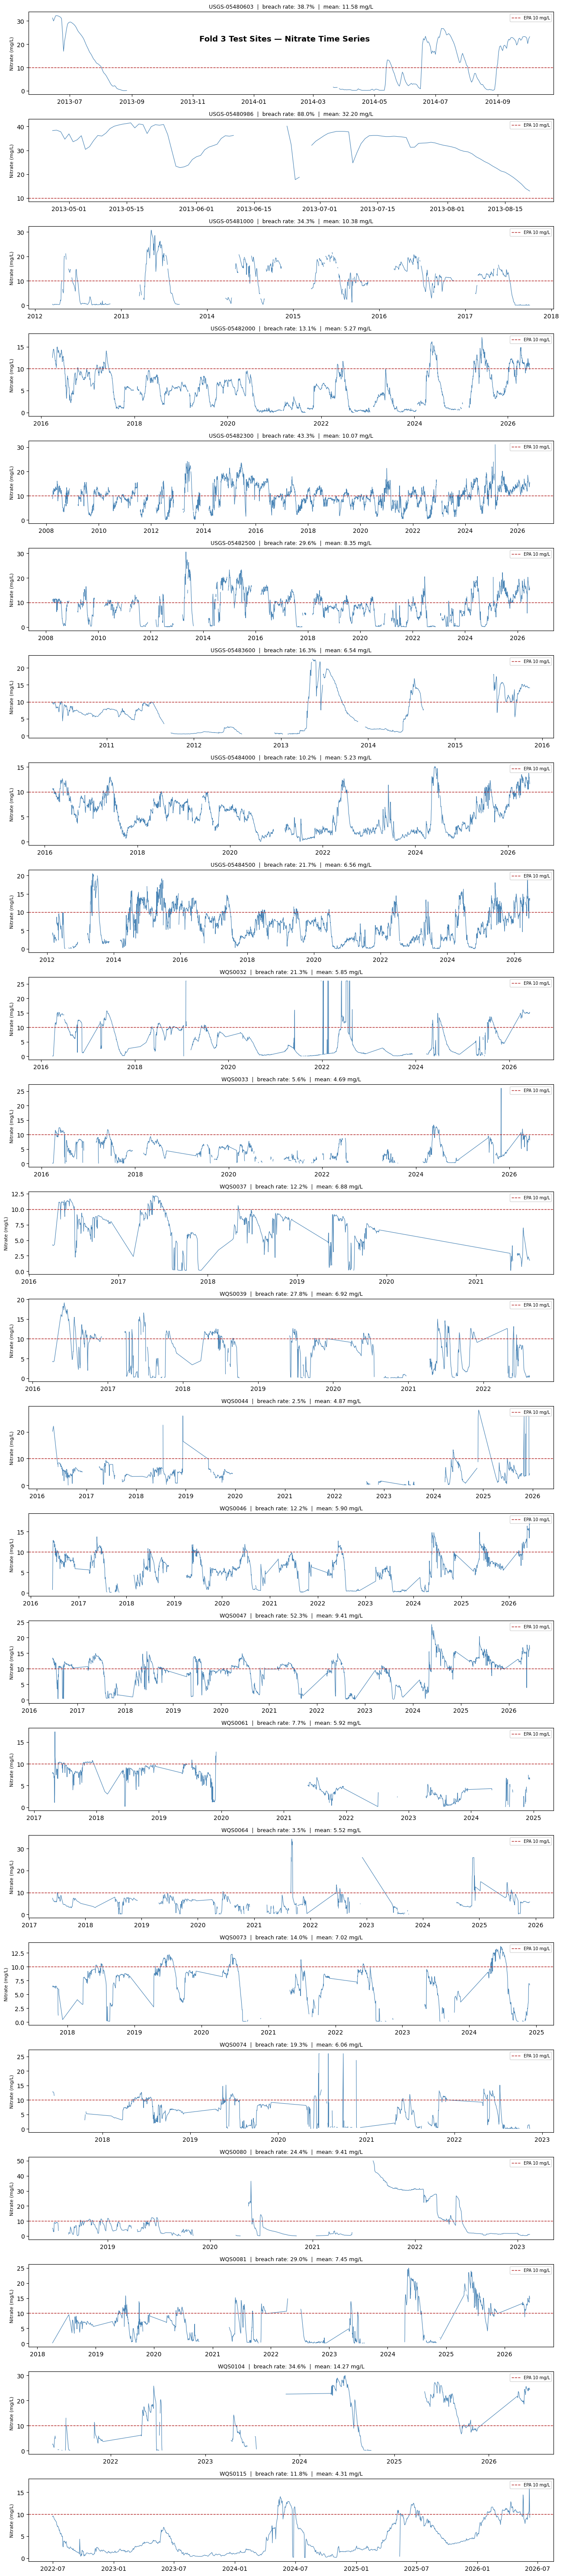

In [ ]:
import sys
sys.path.insert(0, "../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.splits import make_folds, audit_split

from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import ParameterGrid

# =============================================================================
# 1. LOAD DATA
# =============================================================================
df = pd.read_parquet('df_master_raw_hydrology.parquet')
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

# =============================================================================
# 2. DEFINE BINARY TARGET: EPA 10 mg/L MCL
# =============================================================================
EPA_THRESHOLD = 10.0
df['nitrate_breach'] = (df['nitrate_con'] > EPA_THRESHOLD).astype(int)
breach_rate = df['nitrate_breach'].mean()
print(f"Breach prevalence: {breach_rate:.2%}  →  random-guess PR-AUC baseline ≈ {breach_rate:.4f}")

# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================

# --- 3a. Cyclic Encoding of Temporal Features ---
# Raw month/doy/week integers are ordinal, not cyclic: the model would see Dec(12)
# and Jan(1) as maximally distant when they are adjacent. Sin/cos encoding wraps
# the calendar so proximity is preserved. We also retain the raw integers because
# XGBoost can use both — the integer captures monotone seasonal trends while the
# trig pair captures cyclic adjacency.
def add_cyclic(df, col, period):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
    return df

df = add_cyclic(df, 'month',       period=12)
df = add_cyclic(df, 'day_of_year', period=365)
df = add_cyclic(df, 'week',        period=52)

# --- 3b. Seasonal Interaction Features ---
# Fertilizer application peaks Apr-May; spring/summer rain flushes nitrate into
# streams via tile drains. Encoding these cross-products makes the dominant
# physical loading mechanism explicit rather than requiring the booster to
# reconstruct it through many nested splits.
df['spring_flag'] = df['month'].isin([3, 4, 5]).astype(int)
df['summer_flag'] = df['month'].isin([6, 7, 8]).astype(int)

df['spring_rain_7d']   = df['spring_flag'] * df['rain_roll_7d']
df['spring_rain_30d']  = df['spring_flag'] * df['rain_roll_30d']
df['spring_corn_rain'] = df['spring_flag'] * df['w_Corn_short'] * df['rain_roll_7d']

if 'basin_area' in df.columns:
    df['volume_proxy_30d'] = df['rain_roll_30d'] * df['basin_area']
    df['volume_proxy_90d'] = df['rain_roll_90d'] * df['basin_area']

# Log-transform basin area: sites span four orders of magnitude (1.8M to 4.2B),
# so raw area causes XGBoost to waste splits on scale rather than hydrology.
# Log compresses the range and lets the model split meaningfully across sizes.
df["log_basin_area"] = np.log1p(df["basin_area"])

# Historical nitrate baselines intentionally excluded.
# Providing the model with a site's prior mean nitrate (even leak-free) is
# nearly circular — it answers "will this site breach?" with "has it breached
# before?", which trivializes the prediction and tells us nothing about the
# physical drivers (land use, rainfall, basin geometry) we actually care about.
# The interesting question is whether those drivers alone predict breach risk
# at sites where we may have no prior nitrate record at all.

# =============================================================================
# 4. DEFINE FEATURE COLUMNS
# =============================================================================
id_col    = 'site_uid' if 'site_uid' in df.columns else 'site_id'
drop_cols = {id_col, 'date', 'nitrate_con', 'nitrate_breach',
             'basin_area',   # replaced by log_basin_area
            }

# --- Lat/lon: include, with explanation ---
# The conflict-graph splitter guarantees that no held-out site shares spatial
# containment AND temporal overlap with any training site. Coordinates therefore
# cannot function as a look-up key for test-site target values. Instead they act
# as legitimate regional proxies for geology, climate zone, and soil type —
# information that genuinely predicts nitrate regime. We keep them.
# (If you ever switch to a weaker splitter, revisit this decision.)
geo_cols = [c for c in df.columns
            if any(k in c.lower() for k in ['lat', 'lon', 'lng', 'latitude', 'longitude'])]
if geo_cols:
    print(f"Including geo columns as regional proxies: {geo_cols}")

feature_cols = [c for c in df.columns if c not in drop_cols]
print(f"\nFeature matrix: {len(feature_cols)} features")

# =============================================================================
# 5. HYPERPARAMETER GRID
# =============================================================================
PARAM_GRID = list(ParameterGrid({
    'max_depth':        [4, 6],      # most impactful structural param
    'learning_rate':    [0.03, 0.05],
    'n_estimators':     [600],       # ceiling; early stopping fires well before this
    'subsample':        [0.8],       # fixed — low sensitivity, saves 2x fits
    'colsample_bytree': [0.8],       # fixed — low sensitivity, saves 2x fits
    'reg_alpha':        [0.0],       # fixed — tree structure already regularizes
    'reg_lambda':       [1.0],       # fixed — XGBoost default is well-calibrated
    'min_child_weight': [3, 10],     # min hessian sum per leaf — controls overfitting
}))
# 2 × 2 × 2 = 8 configs; 8 × 2 inner × 4 outer = 64 total fits
print(f"Grid search space: {len(PARAM_GRID)} configurations")

# =============================================================================
# 6. OUTER FOLDS  (built once, reused in every outer iteration)
# =============================================================================
RANDOM_STATE = 42
NUM_FOLDS    = 4

# make_folds operates on ALL sites from get_site_ids() internally.
# We filter its output to get train/test site lists for each outer fold.
outer_folds = make_folds(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_STATE)

plt.figure(figsize=(9, 7))
mean_recall         = np.linspace(0, 1, 100)
precisions_all      = []
fold_auc_scores     = []
best_params_by_fold = []

print(f"\n{'='*60}")
print(f"Starting {NUM_FOLDS}-Fold Spatial CV with Inner Grid Search")
print(f"{'='*60}\n")

# =============================================================================
# 7. NESTED CV LOOP
# =============================================================================
for fold_idx in range(NUM_FOLDS):
    print(f"--- Outer Fold {fold_idx + 1}/{NUM_FOLDS} ---")

    # --- Outer split ---
    test_sites  = outer_folds.index[outer_folds.fold == fold_idx].tolist()
    train_sites = outer_folds.index[outer_folds.fold != fold_idx].tolist()

    assert audit_split(train_sites, test_sites).query("severity == 'hard'").empty, \
        f"Fold {fold_idx + 1}: hard spatial leak detected — check conflict graph!"

    df_train_outer = df[df[id_col].isin(train_sites)]
    df_test_outer  = df[df[id_col].isin(test_sites)]

    X_test_outer = df_test_outer[feature_cols]
    y_test_outer = df_test_outer['nitrate_breach']

    # --- Inner folds for hyperparameter tuning ---
    # make_folds has no site_pool argument, so we call it globally and then
    # restrict to the training sites of this outer fold by filtering the table.
    inner_fold_table = make_folds(
        n_splits=2,   # 2 inner folds — enough to rank configs, much faster
        shuffle=True,
        random_state=RANDOM_STATE
    )
    # Keep only rows that correspond to outer-training sites, then re-index
    # folds 0..NUM_FOLDS-2 within that restricted pool.
    inner_fold_table = inner_fold_table[inner_fold_table.index.isin(train_sites)].copy()

    # --- Inner grid search ---
    best_inner_auc = -1.0
    best_params    = PARAM_GRID[0]

    for params in PARAM_GRID:
        inner_aucs = []

        for inner_idx in inner_fold_table['fold'].unique():
            inner_test_sites  = inner_fold_table.index[inner_fold_table.fold == inner_idx].tolist()
            inner_train_sites = inner_fold_table.index[inner_fold_table.fold != inner_idx].tolist()

            # Restrict both pools to outer-training sites (already guaranteed by
            # the filter above, but explicit for clarity)
            inner_train_sites = [s for s in inner_train_sites if s in set(train_sites)]
            inner_test_sites  = [s for s in inner_test_sites  if s in set(train_sites)]

            df_it = df_train_outer[df_train_outer[id_col].isin(inner_train_sites)]
            df_iv = df_train_outer[df_train_outer[id_col].isin(inner_test_sites)]

            X_it, y_it = df_it[feature_cols], df_it['nitrate_breach']
            X_iv, y_iv = df_iv[feature_cols], df_iv['nitrate_breach']

            # Downsample majority class 2:1 on training split only
            idx_neg = y_it[y_it == 0].index
            idx_pos = y_it[y_it == 1].index
            n_sample = min(len(idx_neg), len(idx_pos) * 2)
            rng = np.random.default_rng(RANDOM_STATE)
            sampled_neg = rng.choice(idx_neg, size=n_sample, replace=False)
            bal_idx = np.concatenate([idx_pos, sampled_neg])
            X_bal, y_bal = X_it.loc[bal_idx], y_it.loc[bal_idx]

            imbalance_ratio = (y_bal == 0).sum() / max(1, (y_bal == 1).sum())

            m = XGBClassifier(
                objective='binary:logitraw',
                eval_metric='aucpr',
                early_stopping_rounds=25,
                tree_method='hist',
                n_jobs=-1,
                random_state=RANDOM_STATE,
                scale_pos_weight=imbalance_ratio,
                **params
            )
            m.fit(X_bal, y_bal, eval_set=[(X_iv, y_iv)], verbose=False)

            scores = m.predict(X_iv, output_margin=True)
            prec, rec, _ = precision_recall_curve(y_iv, scores)
            inner_aucs.append(auc(rec, prec))

        mean_inner_auc = np.mean(inner_aucs)
        if mean_inner_auc > best_inner_auc:
            best_inner_auc = mean_inner_auc
            best_params    = params

    best_params_by_fold.append(best_params)
    print(f"  Best inner PR-AUC : {best_inner_auc:.4f}")
    print(f"  Best params       : {best_params}")

    # --- Retrain on full outer training set with winning params ---
    X_train_full = df_train_outer[feature_cols]
    y_train_full = df_train_outer['nitrate_breach']

    idx_neg = y_train_full[y_train_full == 0].index
    idx_pos = y_train_full[y_train_full == 1].index
    n_sample = min(len(idx_neg), len(idx_pos) * 2)
    rng = np.random.default_rng(RANDOM_STATE)
    sampled_neg = rng.choice(idx_neg, size=n_sample, replace=False)
    bal_idx = np.concatenate([idx_pos, sampled_neg])
    X_bal_full = X_train_full.loc[bal_idx]
    y_bal_full = y_train_full.loc[bal_idx]
    imbalance_ratio = (y_bal_full == 0).sum() / max(1, (y_bal_full == 1).sum())

    final_model = XGBClassifier(
        objective='binary:logitraw',
        eval_metric='aucpr',
        early_stopping_rounds=30,
        tree_method='hist',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        scale_pos_weight=imbalance_ratio,
        **best_params
    )
    final_model.fit(
        X_bal_full, y_bal_full,
        eval_set=[(X_test_outer, y_test_outer)],
        verbose=False
    )

    # --- Outer evaluation ---
    scores_outer = final_model.predict(X_test_outer, output_margin=True)
    prec_outer, rec_outer, _ = precision_recall_curve(y_test_outer, scores_outer)
    fold_auc = auc(rec_outer, prec_outer)
    fold_auc_scores.append(fold_auc)

    plt.plot(rec_outer, prec_outer, alpha=0.3, linestyle='--',
             label=f'Fold {fold_idx + 1} (AUC = {fold_auc:.4f})')

    interp_prec = np.interp(mean_recall, rec_outer[::-1], prec_outer[::-1])
    precisions_all.append(interp_prec)

    print(f"  Outer PR-AUC      : {fold_auc:.4f}\n")

# =============================================================================
# 8. AGGREGATE & PLOT RESULTS
# =============================================================================
mean_auc = np.mean(fold_auc_scores)
std_auc  = np.std(fold_auc_scores)

print(f"{'='*60}")
print(f"FINAL RESULTS")
print(f"Mean Out-of-Network PR-AUC : {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Random-guess baseline      : {breach_rate:.4f}")
print(f"{'='*60}")

mean_precision = np.mean(precisions_all, axis=0)
mean_curve_auc = auc(mean_recall, mean_precision)

plt.plot(mean_recall, mean_precision, color='firebrick', lw=2.5,
         label=f'Mean PR-AUC = {mean_curve_auc:.4f} ± {std_auc:.4f}')
plt.axhline(y=breach_rate, color='gray', linestyle=':', lw=1.5,
            label=f'Random Guess Baseline ({breach_rate:.3f})')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Recall (Sensitivity / Catching Breaches)', fontsize=12)
plt.ylabel('Precision (Reliability / Avoiding False Alarms)', fontsize=12)
plt.title('Out-of-Network Precision-Recall Curve\n(Conflict-Graph Spatial CV + Nested Grid Search)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pr_curve_nitrate_breach.png', dpi=150)
plt.show()

# =============================================================================
# 9. FEATURE IMPORTANCE (last fold model — for inspection)
# =============================================================================
importances = pd.Series(
    final_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances (last fold model):")
print(importances.head(20).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
importances.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — Nitrate Breach Classifier', fontweight='bold')
ax.set_xlabel('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('feature_importance_nitrate_breach.png', dpi=150)
plt.show()

# =============================================================================
# 10. BEST HYPERPARAMETERS PER FOLD
# =============================================================================
print("\nBest hyperparameters selected per outer fold:")
for i, p in enumerate(best_params_by_fold):
    print(f"  Fold {i + 1}: {p}")

# =============================================================================
# 11. FOLD 3 DIAGNOSTIC
# =============================================================================
FOLD3_IDX = 2  # 0-indexed

fold3_test_sites  = outer_folds.index[outer_folds.fold == FOLD3_IDX].tolist()
fold3_train_sites = outer_folds.index[outer_folds.fold != FOLD3_IDX].tolist()

df_fold3_test  = df[df[id_col].isin(fold3_test_sites)]
df_fold3_train = df[df[id_col].isin(fold3_train_sites)]

print(f"\n{'='*60}")
print(f"FOLD 3 DIAGNOSTIC")
print(f"  Test sites : {len(fold3_test_sites)}")
print(f"  Train sites: {len(fold3_train_sites)}")
print(f"{'='*60}")

# --- Per-site summary for test sites ---
KEY_FEATURES = [
    'nitrate_con', 'nitrate_breach', 'basin_area',
    'w_Corn_short', 'w_surplus_short', 'rain_roll_30d',
    'rain_roll_90d', 'w_Nonag_short', 'w_Hay_Pasture_short',
]
available = [c for c in KEY_FEATURES if c in df.columns]

site_stats = (
    df_fold3_test
    .groupby(id_col)[available]
    .agg(['mean', 'std', 'median'])
)
site_stats.columns = ['_'.join(c) for c in site_stats.columns]
site_stats['breach_rate'] = df_fold3_test.groupby(id_col)['nitrate_breach'].mean()
site_stats['n_records']   = df_fold3_test.groupby(id_col)['nitrate_breach'].count()
site_stats = site_stats.sort_values('nitrate_con_mean', ascending=False)

print("\nPer-site summary (Fold 3 test sites), sorted by mean nitrate:")
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.3f}'.format)
print(site_stats[['n_records', 'breach_rate', 'nitrate_con_mean', 'nitrate_con_std',
                   'basin_area_mean', 'w_Corn_short_mean', 'w_surplus_short_mean']].to_string())

# --- Compare test vs train distributions on key features ---
compare_cols = ['nitrate_con', 'basin_area', 'w_Corn_short',
                'w_surplus_short', 'rain_roll_30d', 'rain_roll_90d']
compare_cols = [c for c in compare_cols if c in df.columns]

print(f"\n{'─'*60}")
print("Feature distribution comparison: Fold 3 test vs training data")
print(f"{'─'*60}")
print(f"{'Feature':<22}  {'Train mean':>10}  {'Test mean':>10}  {'Train median':>12}  {'Test median':>11}  {'Δ mean %':>9}")
print(f"{'─'*60}")
for col in compare_cols:
    tr_mean = df_fold3_train[col].mean()
    te_mean = df_fold3_test[col].mean()
    tr_med  = df_fold3_train[col].median()
    te_med  = df_fold3_test[col].median()
    delta   = (te_mean - tr_mean) / (abs(tr_mean) + 1e-9) * 100
    print(f"{col:<22}  {tr_mean:>10.3f}  {te_mean:>10.3f}  {tr_med:>12.3f}  {te_med:>11.3f}  {delta:>+9.1f}%")

# --- Breach rate comparison ---
train_breach = df_fold3_train['nitrate_breach'].mean()
test_breach  = df_fold3_test['nitrate_breach'].mean()
print(f"\n{'─'*60}")
print(f"Breach rate  →  Train: {train_breach:.2%}   Test: {test_breach:.2%}")
print(f"{'─'*60}")

# --- Basin area distribution: are test basins outliers? ---
print(f"\nBasin area percentiles (train vs test):")
for pct in [10, 25, 50, 75, 90]:
    tr_p = df_fold3_train['basin_area'].quantile(pct/100) if 'basin_area' in df.columns else float('nan')
    te_p = df_fold3_test['basin_area'].quantile(pct/100)  if 'basin_area' in df.columns else float('nan')
    print(f"  p{pct:02d}:  Train {tr_p:>14.0f}   Test {te_p:>14.0f}")

# --- Visualizations ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Fold 3 Diagnostic: Test Sites vs Training Distribution', fontsize=14, fontweight='bold')

plot_cols = ['nitrate_con', 'basin_area', 'w_Corn_short',
             'w_surplus_short', 'rain_roll_30d', 'w_Nonag_short']
plot_cols = [c for c in plot_cols if c in df.columns]

for ax, col in zip(axes.flat, plot_cols):
    # Clip extreme tails for readability
    lo = df_fold3_train[col].quantile(0.01)
    hi = df_fold3_train[col].quantile(0.99)
    tr_clipped = df_fold3_train[col].clip(lo, hi)
    te_clipped = df_fold3_test[col].clip(lo, hi)

    ax.hist(tr_clipped, bins=40, alpha=0.5, color='steelblue',
            density=True, label='Train')
    ax.hist(te_clipped, bins=40, alpha=0.6, color='firebrick',
            density=True, label='Fold 3 Test')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fold3_diagnostic.png', dpi=150)
plt.show()

# --- Nitrate time series per test site ---
if 'date' in df.columns:
    fig, axes = plt.subplots(
        len(fold3_test_sites), 1,
        figsize=(13, 2.5 * len(fold3_test_sites)),
        sharex=False
    )
    if len(fold3_test_sites) == 1:
        axes = [axes]
    fig.suptitle('Fold 3 Test Sites — Nitrate Time Series', fontsize=13, fontweight='bold')

    for ax, site in zip(axes, fold3_test_sites):
        site_df = df_fold3_test[df_fold3_test[id_col] == site].sort_values('date')
        ax.plot(site_df['date'], site_df['nitrate_con'], lw=0.8, color='steelblue')
        ax.axhline(EPA_THRESHOLD, color='firebrick', linestyle='--', lw=1,
                   label='EPA 10 mg/L')
        br = site_df['nitrate_breach'].mean()
        ax.set_title(f"{site}  |  breach rate: {br:.1%}  |  mean: {site_df['nitrate_con'].mean():.2f} mg/L",
                     fontsize=9)
        ax.set_ylabel('Nitrate (mg/L)', fontsize=8)
        ax.legend(fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.savefig('fold3_timeseries.png', dpi=150)
    plt.show()

In [ ]:
import sys
sys.path.insert(0, "../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.splits import make_folds, audit_split

from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import ParameterGrid

# =============================================================================
# 1. LOAD DATA
# =============================================================================
df = pd.read_parquet('df_master_raw_hydrology.parquet')
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

# =============================================================================
# 2. DEFINE BINARY TARGET: EPA 10 mg/L MCL
# =============================================================================
EPA_THRESHOLD = 10.0
df['nitrate_breach'] = (df['nitrate_con'] > EPA_THRESHOLD).astype(int)
breach_rate = df['nitrate_breach'].mean()
print(f"Breach prevalence: {breach_rate:.2%}  →  random-guess PR-AUC baseline ≈ {breach_rate:.4f}")

# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================

# --- 3a. Cyclic Encoding of Temporal Features ---
# Raw month/doy/week integers are ordinal, not cyclic: the model would see Dec(12)
# and Jan(1) as maximally distant when they are adjacent. Sin/cos encoding wraps
# the calendar so proximity is preserved. We also retain the raw integers because
# XGBoost can use both — the integer captures monotone seasonal trends while the
# trig pair captures cyclic adjacency.
def add_cyclic(df, col, period):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
    return df

df = add_cyclic(df, 'month',       period=12)
df = add_cyclic(df, 'day_of_year', period=365)
df = add_cyclic(df, 'week',        period=52)

# --- 3b. Seasonal Interaction Features ---
# Fertilizer application peaks Apr-May; spring/summer rain flushes nitrate into
# streams via tile drains. Encoding these cross-products makes the dominant
# physical loading mechanism explicit rather than requiring the booster to
# reconstruct it through many nested splits.
df['spring_flag'] = df['month'].isin([3, 4, 5]).astype(int)
df['summer_flag'] = df['month'].isin([6, 7, 8]).astype(int)

df['spring_rain_7d']   = df['spring_flag'] * df['rain_roll_7d']
df['spring_rain_30d']  = df['spring_flag'] * df['rain_roll_30d']
df['spring_corn_rain'] = df['spring_flag'] * df['w_Corn_short'] * df['rain_roll_7d']

if 'basin_area' in df.columns:
    df['volume_proxy_30d'] = df['rain_roll_30d'] * df['basin_area']
    df['volume_proxy_90d'] = df['rain_roll_90d'] * df['basin_area']

# Log-transform basin area: sites span four orders of magnitude (1.8M to 4.2B),
# so raw area causes XGBoost to waste splits on scale rather than hydrology.
# Log compresses the range and lets the model split meaningfully across sizes.
df["log_basin_area"] = np.log1p(df["basin_area"])

# Historical nitrate baselines intentionally excluded.
# Providing the model with a site's prior mean nitrate (even leak-free) is
# nearly circular — it answers "will this site breach?" with "has it breached
# before?", which trivializes the prediction and tells us nothing about the
# physical drivers (land use, rainfall, basin geometry) we actually care about.
# The interesting question is whether those drivers alone predict breach risk
# at sites where we may have no prior nitrate record at all.

# =============================================================================
# 4. DEFINE FEATURE COLUMNS
# =============================================================================
id_col    = 'site_uid' if 'site_uid' in df.columns else 'site_id'
drop_cols = {id_col, 'date', 'nitrate_con', 'nitrate_breach',
             'basin_area',   # replaced by log_basin_area
            }

# --- Lat/lon: include, with explanation ---
# The conflict-graph splitter guarantees that no held-out site shares spatial
# containment AND temporal overlap with any training site. Coordinates therefore
# cannot function as a look-up key for test-site target values. Instead they act
# as legitimate regional proxies for geology, climate zone, and soil type —
# information that genuinely predicts nitrate regime. We keep them.
# (If you ever switch to a weaker splitter, revisit this decision.)
geo_cols = [c for c in df.columns
            if any(k in c.lower() for k in ['lat', 'lon', 'lng', 'latitude', 'longitude'])]
if geo_cols:
    print(f"Including geo columns as regional proxies: {geo_cols}")

feature_cols = [c for c in df.columns if c not in drop_cols]
print(f"\nFeature matrix: {len(feature_cols)} features")

# =============================================================================
# 5. HYPERPARAMETER GRID
# =============================================================================
PARAM_GRID = list(ParameterGrid({
    'max_depth':        [4, 6],      # most impactful structural param
    'learning_rate':    [0.03, 0.05],
    'n_estimators':     [600],       # ceiling; early stopping fires well before this
    'subsample':        [0.8],       # fixed — low sensitivity, saves 2x fits
    'colsample_bytree': [0.8],       # fixed — low sensitivity, saves 2x fits
    'reg_alpha':        [0.0],       # fixed — tree structure already regularizes
    'reg_lambda':       [1.0],       # fixed — XGBoost default is well-calibrated
    'min_child_weight': [3, 10],     # min hessian sum per leaf — controls overfitting
}))
# 2 × 2 × 2 = 8 configs; 8 × 2 inner × 4 outer = 64 total fits
print(f"Grid search space: {len(PARAM_GRID)} configurations")

# =============================================================================
# 6. OUTER FOLDS  (built once, reused in every outer iteration)
# =============================================================================
RANDOM_STATE = 42
NUM_FOLDS    = 4

# make_folds operates on ALL sites from get_site_ids() internally.
# We filter its output to get train/test site lists for each outer fold.
outer_folds = make_folds(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_STATE)

plt.figure(figsize=(9, 7))
mean_recall         = np.linspace(0, 1, 100)
precisions_all      = []
fold_auc_scores     = []
best_params_by_fold = []

print(f"\n{'='*60}")
print(f"Starting {NUM_FOLDS}-Fold Spatial CV with Inner Grid Search")
print(f"{'='*60}\n")

# =============================================================================
# 7. NESTED CV LOOP
# =============================================================================
for fold_idx in range(NUM_FOLDS):
    print(f"--- Outer Fold {fold_idx + 1}/{NUM_FOLDS} ---")

    # --- Outer split ---
    test_sites  = outer_folds.index[outer_folds.fold == fold_idx].tolist()
    train_sites = outer_folds.index[outer_folds.fold != fold_idx].tolist()

    assert audit_split(train_sites, test_sites).query("severity == 'hard'").empty, \
        f"Fold {fold_idx + 1}: hard spatial leak detected — check conflict graph!"

    df_train_outer = df[df[id_col].isin(train_sites)]
    df_test_outer  = df[df[id_col].isin(test_sites)]

    X_test_outer = df_test_outer[feature_cols]
    y_test_outer = df_test_outer['nitrate_breach']

    # --- Inner folds for hyperparameter tuning ---
    # make_folds has no site_pool argument, so we call it globally and then
    # restrict to the training sites of this outer fold by filtering the table.
    inner_fold_table = make_folds(
        n_splits=2,   # 2 inner folds — enough to rank configs, much faster
        shuffle=True,
        random_state=RANDOM_STATE
    )
    # Keep only rows that correspond to outer-training sites, then re-index
    # folds 0..NUM_FOLDS-2 within that restricted pool.
    inner_fold_table = inner_fold_table[inner_fold_table.index.isin(train_sites)].copy()

    # --- Inner grid search ---
    best_inner_auc = -1.0
    best_params    = PARAM_GRID[0]

    for params in PARAM_GRID:
        inner_aucs = []

        for inner_idx in inner_fold_table['fold'].unique():
            inner_test_sites  = inner_fold_table.index[inner_fold_table.fold == inner_idx].tolist()
            inner_train_sites = inner_fold_table.index[inner_fold_table.fold != inner_idx].tolist()

            # Restrict both pools to outer-training sites (already guaranteed by
            # the filter above, but explicit for clarity)
            inner_train_sites = [s for s in inner_train_sites if s in set(train_sites)]
            inner_test_sites  = [s for s in inner_test_sites  if s in set(train_sites)]

            df_it = df_train_outer[df_train_outer[id_col].isin(inner_train_sites)]
            df_iv = df_train_outer[df_train_outer[id_col].isin(inner_test_sites)]

            X_it, y_it = df_it[feature_cols], df_it['nitrate_breach']
            X_iv, y_iv = df_iv[feature_cols], df_iv['nitrate_breach']

            # Downsample majority class 2:1 on training split only
            idx_neg = y_it[y_it == 0].index
            idx_pos = y_it[y_it == 1].index
            n_sample = min(len(idx_neg), len(idx_pos) * 2)
            rng = np.random.default_rng(RANDOM_STATE)
            sampled_neg = rng.choice(idx_neg, size=n_sample, replace=False)
            bal_idx = np.concatenate([idx_pos, sampled_neg])
            X_bal, y_bal = X_it.loc[bal_idx], y_it.loc[bal_idx]

            imbalance_ratio = (y_bal == 0).sum() / max(1, (y_bal == 1).sum())

            m = XGBClassifier(
                objective='binary:logitraw',
                eval_metric='aucpr',
                early_stopping_rounds=25,
                tree_method='hist',
                n_jobs=-1,
                random_state=RANDOM_STATE,
                scale_pos_weight=imbalance_ratio,
                **params
            )
            m.fit(X_bal, y_bal, eval_set=[(X_iv, y_iv)], verbose=False)

            scores = m.predict(X_iv, output_margin=True)
            prec, rec, _ = precision_recall_curve(y_iv, scores)
            inner_aucs.append(auc(rec, prec))

        mean_inner_auc = np.mean(inner_aucs)
        if mean_inner_auc > best_inner_auc:
            best_inner_auc = mean_inner_auc
            best_params    = params

    best_params_by_fold.append(best_params)
    print(f"  Best inner PR-AUC : {best_inner_auc:.4f}")
    print(f"  Best params       : {best_params}")

    # --- Retrain on full outer training set with winning params ---
    X_train_full = df_train_outer[feature_cols]
    y_train_full = df_train_outer['nitrate_breach']

    idx_neg = y_train_full[y_train_full == 0].index
    idx_pos = y_train_full[y_train_full == 1].index
    n_sample = min(len(idx_neg), len(idx_pos) * 2)
    rng = np.random.default_rng(RANDOM_STATE)
    sampled_neg = rng.choice(idx_neg, size=n_sample, replace=False)
    bal_idx = np.concatenate([idx_pos, sampled_neg])
    X_bal_full = X_train_full.loc[bal_idx]
    y_bal_full = y_train_full.loc[bal_idx]
    imbalance_ratio = (y_bal_full == 0).sum() / max(1, (y_bal_full == 1).sum())

    final_model = XGBClassifier(
        objective='binary:logitraw',
        eval_metric='aucpr',
        early_stopping_rounds=30,
        tree_method='hist',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        scale_pos_weight=imbalance_ratio,
        **best_params
    )
    final_model.fit(
        X_bal_full, y_bal_full,
        eval_set=[(X_test_outer, y_test_outer)],
        verbose=False
    )

    # --- Outer evaluation ---
    scores_outer = final_model.predict(X_test_outer, output_margin=True)
    prec_outer, rec_outer, _ = precision_recall_curve(y_test_outer, scores_outer)
    fold_auc = auc(rec_outer, prec_outer)
    fold_auc_scores.append(fold_auc)

    plt.plot(rec_outer, prec_outer, alpha=0.3, linestyle='--',
             label=f'Fold {fold_idx + 1} (AUC = {fold_auc:.4f})')

    interp_prec = np.interp(mean_recall, rec_outer[::-1], prec_outer[::-1])
    precisions_all.append(interp_prec)

    print(f"  Outer PR-AUC      : {fold_auc:.4f}\n")

# =============================================================================
# 8. AGGREGATE & PLOT RESULTS
# =============================================================================
mean_auc = np.mean(fold_auc_scores)
std_auc  = np.std(fold_auc_scores)

print(f"{'='*60}")
print(f"FINAL RESULTS")
print(f"Mean Out-of-Network PR-AUC : {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Random-guess baseline      : {breach_rate:.4f}")
print(f"{'='*60}")

mean_precision = np.mean(precisions_all, axis=0)
mean_curve_auc = auc(mean_recall, mean_precision)

plt.plot(mean_recall, mean_precision, color='firebrick', lw=2.5,
         label=f'Mean PR-AUC = {mean_curve_auc:.4f} ± {std_auc:.4f}')
plt.axhline(y=breach_rate, color='gray', linestyle=':', lw=1.5,
            label=f'Random Guess Baseline ({breach_rate:.3f})')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Recall (Sensitivity / Catching Breaches)', fontsize=12)
plt.ylabel('Precision (Reliability / Avoiding False Alarms)', fontsize=12)
plt.title('Out-of-Network Precision-Recall Curve\n(Conflict-Graph Spatial CV + Nested Grid Search)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pr_curve_nitrate_breach.png', dpi=150)
plt.show()

# =============================================================================
# 9. FEATURE IMPORTANCE (last fold model — for inspection)
# =============================================================================
importances = pd.Series(
    final_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances (last fold model):")
print(importances.head(20).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
importances.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — Nitrate Breach Classifier', fontweight='bold')
ax.set_xlabel('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('feature_importance_nitrate_breach.png', dpi=150)
plt.show()

# =============================================================================
# 10. BEST HYPERPARAMETERS PER FOLD
# =============================================================================
print("\nBest hyperparameters selected per outer fold:")
for i, p in enumerate(best_params_by_fold):
    print(f"  Fold {i + 1}: {p}")

# =============================================================================
# 11. FOLD 3 DIAGNOSTIC
# =============================================================================
FOLD3_IDX = 2  # 0-indexed

fold3_test_sites  = outer_folds.index[outer_folds.fold == FOLD3_IDX].tolist()
fold3_train_sites = outer_folds.index[outer_folds.fold != FOLD3_IDX].tolist()

df_fold3_test  = df[df[id_col].isin(fold3_test_sites)]
df_fold3_train = df[df[id_col].isin(fold3_train_sites)]

print(f"\n{'='*60}")
print(f"FOLD 3 DIAGNOSTIC")
print(f"  Test sites : {len(fold3_test_sites)}")
print(f"  Train sites: {len(fold3_train_sites)}")
print(f"{'='*60}")

# --- Per-site summary for test sites ---
KEY_FEATURES = [
    'nitrate_con', 'nitrate_breach', 'basin_area',
    'w_Corn_short', 'w_surplus_short', 'rain_roll_30d',
    'rain_roll_90d', 'w_Nonag_short', 'w_Hay_Pasture_short',
]
available = [c for c in KEY_FEATURES if c in df.columns]

site_stats = (
    df_fold3_test
    .groupby(id_col)[available]
    .agg(['mean', 'std', 'median'])
)
site_stats.columns = ['_'.join(c) for c in site_stats.columns]
site_stats['breach_rate'] = df_fold3_test.groupby(id_col)['nitrate_breach'].mean()
site_stats['n_records']   = df_fold3_test.groupby(id_col)['nitrate_breach'].count()
site_stats = site_stats.sort_values('nitrate_con_mean', ascending=False)

print("\nPer-site summary (Fold 3 test sites), sorted by mean nitrate:")
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.3f}'.format)
print(site_stats[['n_records', 'breach_rate', 'nitrate_con_mean', 'nitrate_con_std',
                   'basin_area_mean', 'w_Corn_short_mean', 'w_surplus_short_mean']].to_string())

# --- Compare test vs train distributions on key features ---
compare_cols = ['nitrate_con', 'basin_area', 'w_Corn_short',
                'w_surplus_short', 'rain_roll_30d', 'rain_roll_90d']
compare_cols = [c for c in compare_cols if c in df.columns]

print(f"\n{'─'*60}")
print("Feature distribution comparison: Fold 3 test vs training data")
print(f"{'─'*60}")
print(f"{'Feature':<22}  {'Train mean':>10}  {'Test mean':>10}  {'Train median':>12}  {'Test median':>11}  {'Δ mean %':>9}")
print(f"{'─'*60}")
for col in compare_cols:
    tr_mean = df_fold3_train[col].mean()
    te_mean = df_fold3_test[col].mean()
    tr_med  = df_fold3_train[col].median()
    te_med  = df_fold3_test[col].median()
    delta   = (te_mean - tr_mean) / (abs(tr_mean) + 1e-9) * 100
    print(f"{col:<22}  {tr_mean:>10.3f}  {te_mean:>10.3f}  {tr_med:>12.3f}  {te_med:>11.3f}  {delta:>+9.1f}%")

# --- Breach rate comparison ---
train_breach = df_fold3_train['nitrate_breach'].mean()
test_breach  = df_fold3_test['nitrate_breach'].mean()
print(f"\n{'─'*60}")
print(f"Breach rate  →  Train: {train_breach:.2%}   Test: {test_breach:.2%}")
print(f"{'─'*60}")

# --- Basin area distribution: are test basins outliers? ---
print(f"\nBasin area percentiles (train vs test):")
for pct in [10, 25, 50, 75, 90]:
    tr_p = df_fold3_train['basin_area'].quantile(pct/100) if 'basin_area' in df.columns else float('nan')
    te_p = df_fold3_test['basin_area'].quantile(pct/100)  if 'basin_area' in df.columns else float('nan')
    print(f"  p{pct:02d}:  Train {tr_p:>14.0f}   Test {te_p:>14.0f}")

# --- Visualizations ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Fold 3 Diagnostic: Test Sites vs Training Distribution', fontsize=14, fontweight='bold')

plot_cols = ['nitrate_con', 'basin_area', 'w_Corn_short',
             'w_surplus_short', 'rain_roll_30d', 'w_Nonag_short']
plot_cols = [c for c in plot_cols if c in df.columns]

for ax, col in zip(axes.flat, plot_cols):
    # Clip extreme tails for readability
    lo = df_fold3_train[col].quantile(0.01)
    hi = df_fold3_train[col].quantile(0.99)
    tr_clipped = df_fold3_train[col].clip(lo, hi)
    te_clipped = df_fold3_test[col].clip(lo, hi)

    ax.hist(tr_clipped, bins=40, alpha=0.5, color='steelblue',
            density=True, label='Train')
    ax.hist(te_clipped, bins=40, alpha=0.6, color='firebrick',
            density=True, label='Fold 3 Test')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fold3_diagnostic.png', dpi=150)
plt.show()

# --- Nitrate time series per test site ---
if 'date' in df.columns:
    fig, axes = plt.subplots(
        len(fold3_test_sites), 1,
        figsize=(13, 2.5 * len(fold3_test_sites)),
        sharex=False
    )
    if len(fold3_test_sites) == 1:
        axes = [axes]
    fig.suptitle('Fold 3 Test Sites — Nitrate Time Series', fontsize=13, fontweight='bold')

    for ax, site in zip(axes, fold3_test_sites):
        site_df = df_fold3_test[df_fold3_test[id_col] == site].sort_values('date')
        ax.plot(site_df['date'], site_df['nitrate_con'], lw=0.8, color='steelblue')
        ax.axhline(EPA_THRESHOLD, color='firebrick', linestyle='--', lw=1,
                   label='EPA 10 mg/L')
        br = site_df['nitrate_breach'].mean()
        ax.set_title(f"{site}  |  breach rate: {br:.1%}  |  mean: {site_df['nitrate_con'].mean():.2f} mg/L",
                     fontsize=9)
        ax.set_ylabel('Nitrate (mg/L)', fontsize=8)
        ax.legend(fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.savefig('fold3_timeseries.png', dpi=150)
    plt.show()